# Simulation Demo

This notebook demonstrates the `PhysComp.sim` module, which simulates an azimuthal scattering dataset

### Functions covered:
- `sim.periodic` — simulates 3D dataset

#### Needed Functions

In [9]:
### Needed imports for functions
import numpy as np
from pathlib import Path
from typing import Tuple, Dict, Optional

### Import for plotting
import matplotlib.pyplot as plt

### Importing simulation functions
import PhysComp.sim as sim

### sim_dataset

Function simulates a rudimentary azimuthal scattering dataset for given spatial and spectral dimensions. It applied noise based on given constants to mimic real detector data. The function returns the 3-D detector array, 3-D ground truth array and a 1-D param array.

Underlying ground truth calculated by:
**Ground Truth $= A_{1} sin(x + {\phi}_1) + A_2 sin(2x + {\phi}_2) + O$**
#### Where:
#### $A_1$ , $A_2$ = Randomly Generated Amplitudes
#### $\phi_1$ , $\phi_2$ = Randomly Generated Phases
#### O = Offset To Ensure Positive Signal

#### A demonstration of the underlying signal generated using the function is shown in Figure 1a and Figure 2a

#### Simulated Detector Data calculated by:

### Detector Data = Ground Truth + Poisson Noise + Gaussian Noise

#### Where:
#### Poisson Noise and Gaussian Noise are generated from respective input parameters and numpy functions

## Using The Function

In [18]:
X = 200 # X dimension size
Y = 200 # Y dimension size
Bins = 360 # Spectral bins
Poisson = 100 # Constant defining possion noise
Gaussian = 100 # Constant defining Gaussian noise
Seed = 123456789 # Generation seed

### Simulating dataset of 200x200 with 360 bins
simmed_data = sim.sim_dataset(X,Y,Bins,Poisson,Gaussian, seed = Seed)

#### The rest of the notebook visuals single degree slices in Figure 1 and a single pixel signal in Figure 2

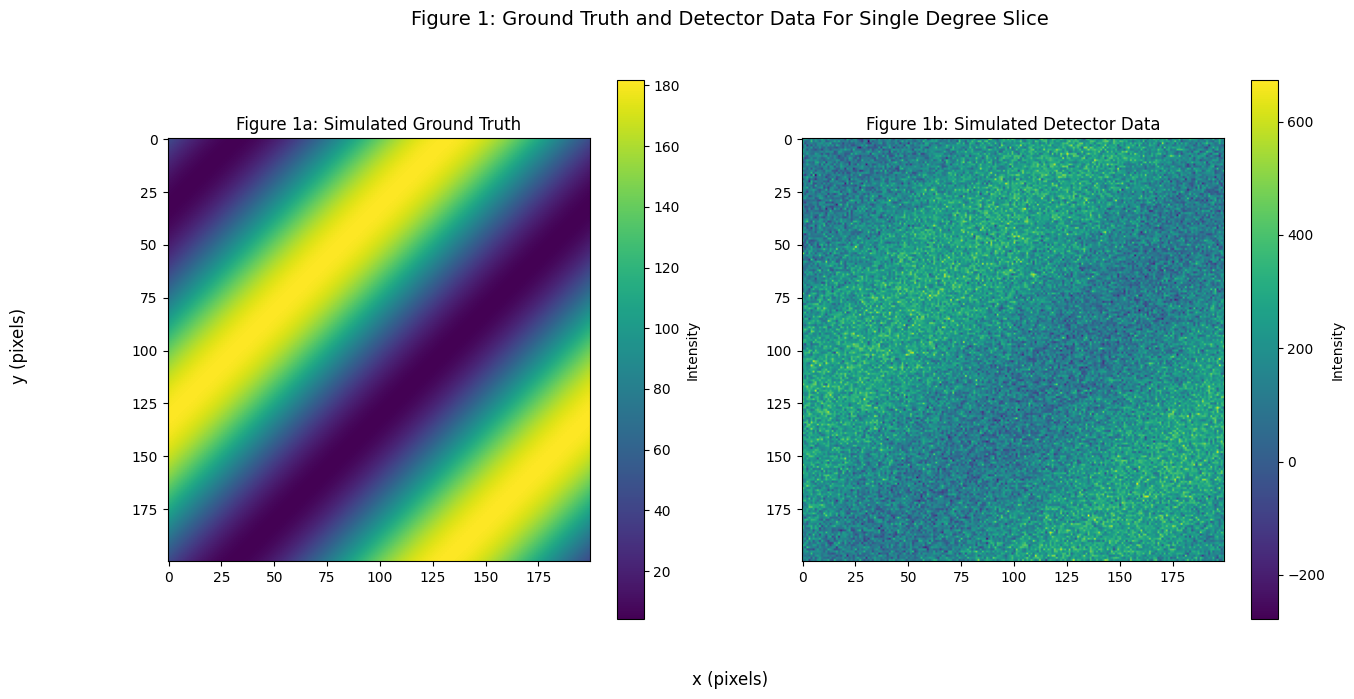

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
plt.suptitle("Figure 1: Ground Truth and Detector Data For Single Degree Slice", fontsize=14)
fig.supxlabel("x (pixels)", fontsize=12)
fig.supylabel("y (pixels)", fontsize=12)  # axes are spatial, not intensity

im0 = axes[0].imshow(simmed_data[1][:,:,0])
axes[0].set_title("Figure 1a: Simulated Ground Truth", fontsize=12)
fig.colorbar(im0, ax=axes[0], label="Intensity")

im1 = axes[1].imshow(simmed_data[0][:,:,0])
axes[1].set_title("Figure 1b: Simulated Detector Data", fontsize=12)
fig.colorbar(im1, ax=axes[1], label="Intensity")

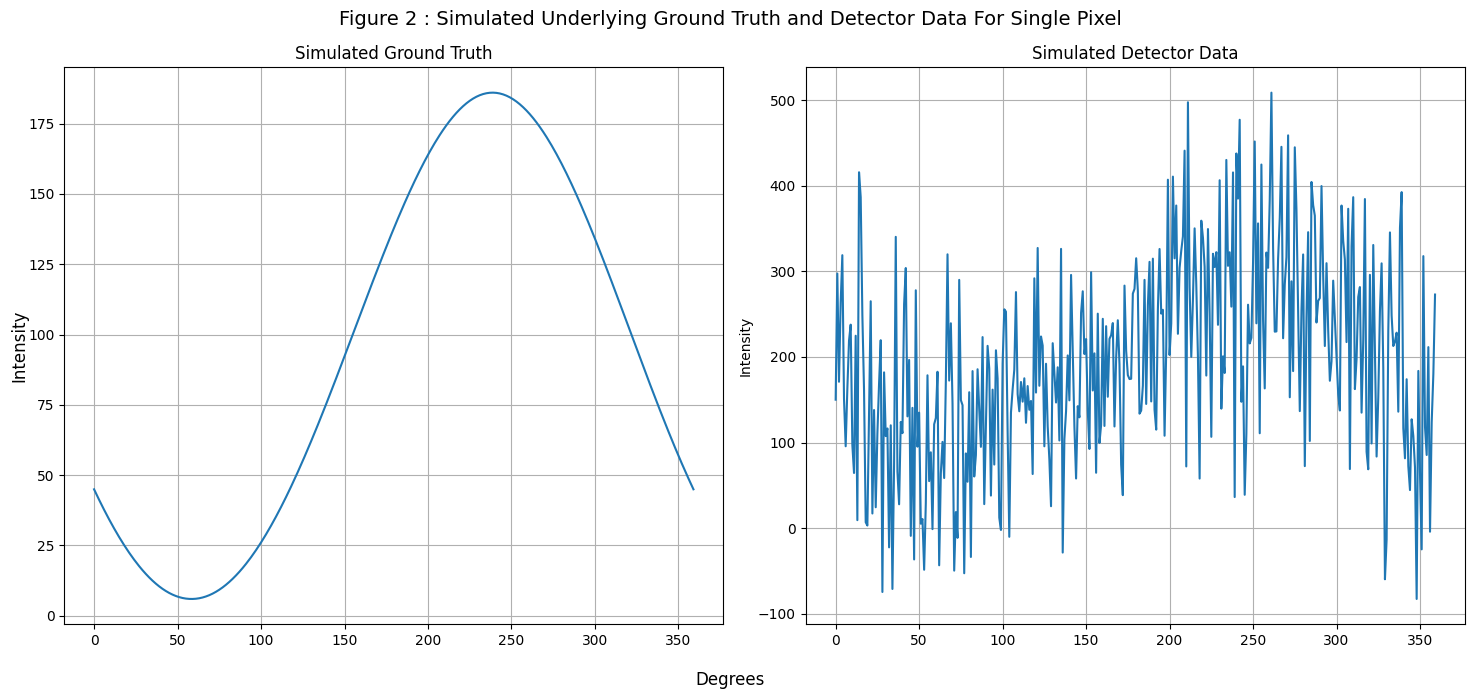

In [19]:
fig, axes = plt.subplots(1, 2,figsize=(15,7))
plt.suptitle("Figure 2 : Simulated Underlying Ground Truth and Detector Data For Single Pixel",fontsize=14)
fig.supxlabel("Degrees",fontsize=12)
fig.supylabel("Intensity",fontsize=12)


im0 = axes[0].plot(simmed_data[1][0,0])
axes[0].set_title("Simulated Ground Truth",fontsize=12)
axes[0].grid(True)

im1 = axes[1].plot(simmed_data[0][0,[0])
axes[1].set_title("Simulated Detector Data",fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()